# Statistical Testing Demo

This notebook demonstrates **feature-wise statistical testing** for detecting shortcuts.

## How Statistical Testing Works

For each embedding dimension, we perform statistical tests (Mann-Whitney U, t-test, etc.) to check if groups differ significantly.

- **Binary case**: One comparison (group 0 vs group 1)
- **Multi-class**: Pairwise (0 vs 1, 0 vs 2, etc.) + one-vs-rest comparisons

Low p-values (<0.05) indicate dimensions that encode group information.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, ttest_ind, ks_2samp

from shortcut_detect.statistical import GroupDiffTest
from shortcut_detect import generate_linear_shortcut, generate_multiclass_shortcut

print("✅ Imports successful!")

✅ Imports successful!


In [2]:
# Create output directory for saving visualizations
import os
os.makedirs('../output', exist_ok=True)
print("✅ Output directory ready")

✅ Output directory ready


## Example 1: Binary Classification

In [3]:
# Generate data with shortcuts in first 3 dimensions
embeddings, labels = generate_linear_shortcut(
    n_samples=1000,
    embedding_dim=30,
    shortcut_dims=3,
    seed=42
)

print(f"Embeddings: {embeddings.shape}")
print(f"Classes: {np.unique(labels)}")

Embeddings: (1000, 30)
Classes: [0 1]


In [4]:
# Run Mann-Whitney U test
test = GroupDiffTest(test=mannwhitneyu)
test.fit(embeddings, labels)

# Get p-values
p_values = test.get_pvalues()
print(f"Comparisons: {list(p_values.keys())}")
print(f"\nP-values for 0_vs_1:")
print(p_values['0_vs_1'][:10])  # First 10 dimensions

Comparisons: ['0_vs_1']

P-values for 0_vs_1:
[6.88649158e-165 6.80432145e-165 7.26869393e-165 3.35359723e-001
 7.45406511e-001 8.99693969e-001 7.05494858e-002 6.97529918e-001
 9.61132316e-001 7.16417947e-001]


In [5]:
# Apply significance threshold
significant = test.apply_threshold(alpha=0.01, verbose=True)

SUMMARY:
[0_vs_1] 3/30 features significant (10.0% below α=0.01)


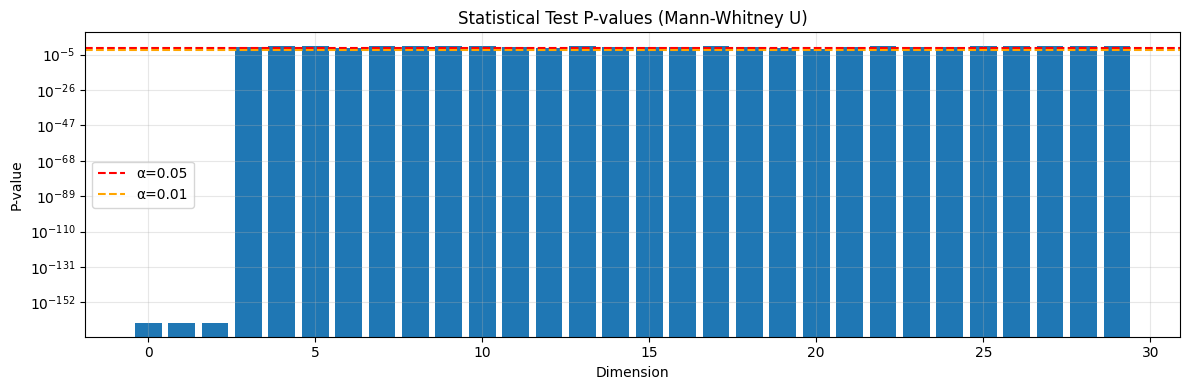

In [6]:
# Visualize p-values
plt.figure(figsize=(12, 4))
plt.bar(range(30), p_values['0_vs_1'])
plt.axhline(y=0.05, color='r', linestyle='--', label='α=0.05')
plt.axhline(y=0.01, color='orange', linestyle='--', label='α=0.01')
plt.xlabel('Dimension')
plt.ylabel('P-value')
plt.title('Statistical Test P-values (Mann-Whitney U)')
plt.legend()
plt.yscale('log')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../output/statistical_pvalues_binary.png', dpi=150)
plt.show()

## Example 2: Multi-class Problem

In [7]:
# Generate 3-class data
embeddings_mc, labels_mc = generate_multiclass_shortcut(
    n_samples=1200,
    embedding_dim=20,
    n_classes=3,
    seed=100
)

print(f"Classes: {np.unique(labels_mc)}")
print(f"Class distribution: {np.bincount(labels_mc)}")

Classes: [0 1 2]
Class distribution: [412 383 405]


In [8]:
# Run tests (using t-test this time)
test_mc = GroupDiffTest(test=ttest_ind)
test_mc.fit(embeddings_mc, labels_mc)

p_values_mc = test_mc.get_pvalues()
print(f"Comparisons performed: {list(p_values_mc.keys())}")

Comparisons performed: ['0_vs_1', '0_vs_2', '1_vs_2', '0_vs_rest', '1_vs_rest', '2_vs_rest']


In [9]:
# Apply threshold
significant_mc = test_mc.apply_threshold(alpha=0.05, verbose=True)

SUMMARY:
[0_vs_1] 2/20 features significant (10.0% below α=0.05)
[0_vs_2] 5/20 features significant (25.0% below α=0.05)
[1_vs_2] 6/20 features significant (30.0% below α=0.05)
[0_vs_rest] 3/20 features significant (15.0% below α=0.05)
[1_vs_rest] 3/20 features significant (15.0% below α=0.05)
[2_vs_rest] 6/20 features significant (30.0% below α=0.05)


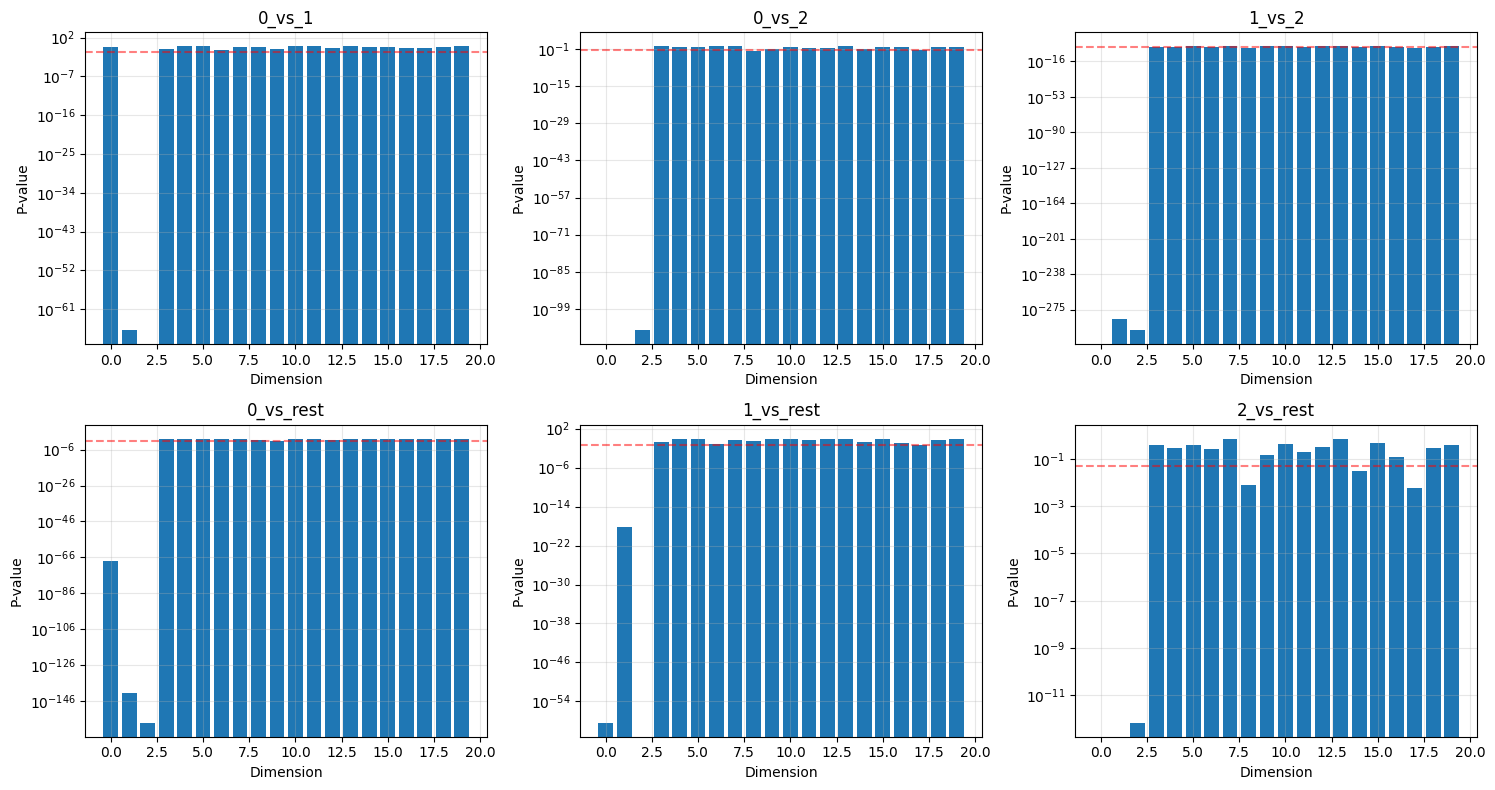

In [10]:
# Visualize all comparisons
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, (comparison, pvals) in enumerate(p_values_mc.items()):
    axes[idx].bar(range(len(pvals)), pvals)
    axes[idx].axhline(y=0.05, color='r', linestyle='--', alpha=0.5)
    axes[idx].set_title(comparison)
    axes[idx].set_xlabel('Dimension')
    axes[idx].set_ylabel('P-value')
    axes[idx].set_yscale('log')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../output/statistical_pvalues_multiclass.png', dpi=150)
plt.show()

## Example 3: Comparing Different Tests

In [11]:
# Compare Mann-Whitney U, t-test, and Kolmogorov-Smirnov
tests = {
    'Mann-Whitney U': mannwhitneyu,
    't-test': ttest_ind,
    'KS test': ks_2samp
}

results = {}
for name, test_fn in tests.items():
    tester = GroupDiffTest(test=test_fn)
    tester.fit(embeddings, labels)
    results[name] = tester.get_pvalues()['0_vs_1']

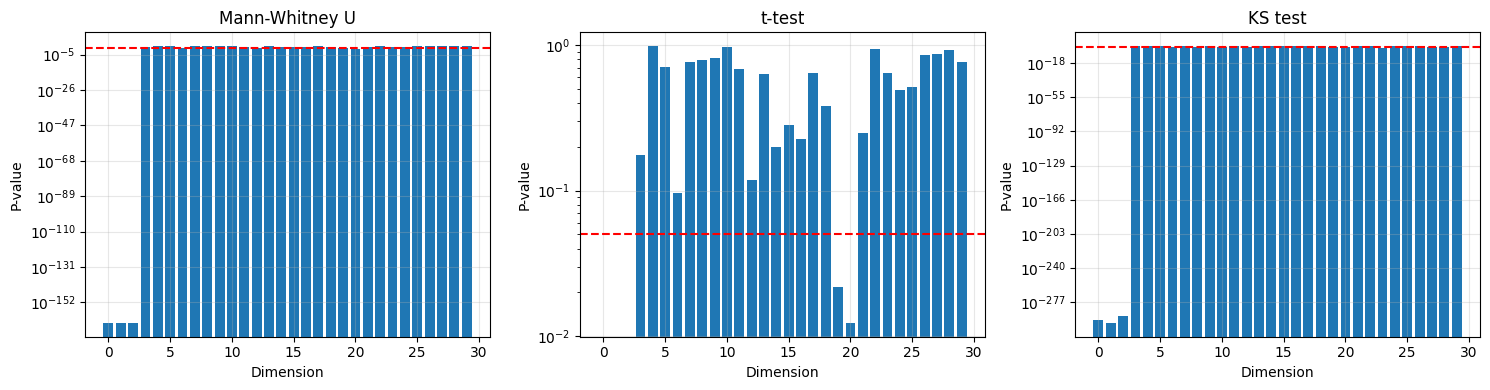

In [12]:
# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, pvals) in enumerate(results.items()):
    axes[idx].bar(range(30), pvals)
    axes[idx].axhline(y=0.05, color='r', linestyle='--')
    axes[idx].set_title(name)
    axes[idx].set_xlabel('Dimension')
    axes[idx].set_ylabel('P-value')
    axes[idx].set_yscale('log')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../output/statistical_test_comparison.png', dpi=150)
plt.show()

## Example 4: Multiple Testing Correction

When testing across many embedding dimensions, **multiple testing correction** is essential to control false positives. Without correction, testing 100 dimensions at α=0.05 would yield ~5 false positives by chance alone.

### The Problem

```
Expected false positives = number_of_tests × α
Example: 512 dimensions × 0.05 = ~25 false positives!
```

### The Solution

The package supports several correction methods:

| Method | Description | Use Case |
|--------|-------------|----------|
| `fdr_bh` | Benjamini-Hochberg FDR | Most applications (default) |
| `bonferroni` | Conservative FWER control | When false positives are costly |
| `holm` | Step-down FWER | Less conservative than Bonferroni |
| `fdr_by` | FDR for dependent tests | Correlated dimensions |

In [13]:
# Generate high-dimensional data to demonstrate multiple testing problem
embeddings_hd, labels_hd = generate_linear_shortcut(
    n_samples=1000,
    embedding_dim=100,  # 100 dimensions
    shortcut_dims=5,     # Only 5 have real shortcuts
    seed=42
)

print(f"Embeddings: {embeddings_hd.shape}")
print(f"True shortcuts in dimensions: 0-4")
print(f"\nWithout correction, we expect ~{100 * 0.05:.0f} false positives at α=0.05")

Embeddings: (1000, 100)
True shortcuts in dimensions: 0-4

Without correction, we expect ~5 false positives at α=0.05


In [14]:
# Fit statistical test
test_hd = GroupDiffTest(test=mannwhitneyu)
test_hd.fit(embeddings_hd, labels_hd)

# Compare raw vs corrected results
print("=" * 60)
print("WITHOUT CORRECTION (risky!)")
print("=" * 60)
raw_significant = test_hd.apply_threshold(alpha=0.05, verbose=True)
n_raw = len(raw_significant['0_vs_1']) if raw_significant['0_vs_1'] else 0

print("\n" + "=" * 60)
print("WITH FDR CORRECTION (Benjamini-Hochberg)")
print("=" * 60)
corrected = test_hd.apply_correction(method='fdr_bh', alpha=0.05, verbose=True)
n_corrected = len(corrected['significant_features']['0_vs_1']) if corrected['significant_features']['0_vs_1'] else 0

print(f"\n📊 Summary:")
print(f"   Raw significant: {n_raw} dimensions")
print(f"   After FDR correction: {n_corrected} dimensions")
print(f"   False positives eliminated: {n_raw - n_corrected}")

WITHOUT CORRECTION (risky!)
SUMMARY:
[0_vs_1] 13/100 features significant (13.0% below α=0.05)

WITH FDR CORRECTION (Benjamini-Hochberg)
Multiple Testing Correction (FDR_BH, α=0.05):
--------------------------------------------------
  [0_vs_1] 5/100 significant after correction (was 13 before)

📊 Summary:
   Raw significant: 13 dimensions
   After FDR correction: 5 dimensions
   False positives eliminated: 8


In [15]:
# Compare different correction methods
methods = ['bonferroni', 'holm', 'fdr_bh', 'fdr_by']
method_results = {}

for method in methods:
    result = test_hd.apply_correction(method=method, alpha=0.05, verbose=False)
    n_sig = len(result['significant_features']['0_vs_1']) if result['significant_features']['0_vs_1'] else 0
    method_results[method] = n_sig

# Add raw (no correction) for comparison
method_results['none (raw)'] = n_raw

# Display comparison
print("Correction Method Comparison:")
print("-" * 40)
for method, n_sig in sorted(method_results.items(), key=lambda x: x[1], reverse=True):
    bar = "█" * n_sig
    print(f"{method:15} | {n_sig:3} significant | {bar}")

Correction Method Comparison:
----------------------------------------
none (raw)      |  13 significant | █████████████
bonferroni      |   5 significant | █████
holm            |   5 significant | █████
fdr_bh          |   5 significant | █████
fdr_by          |   5 significant | █████


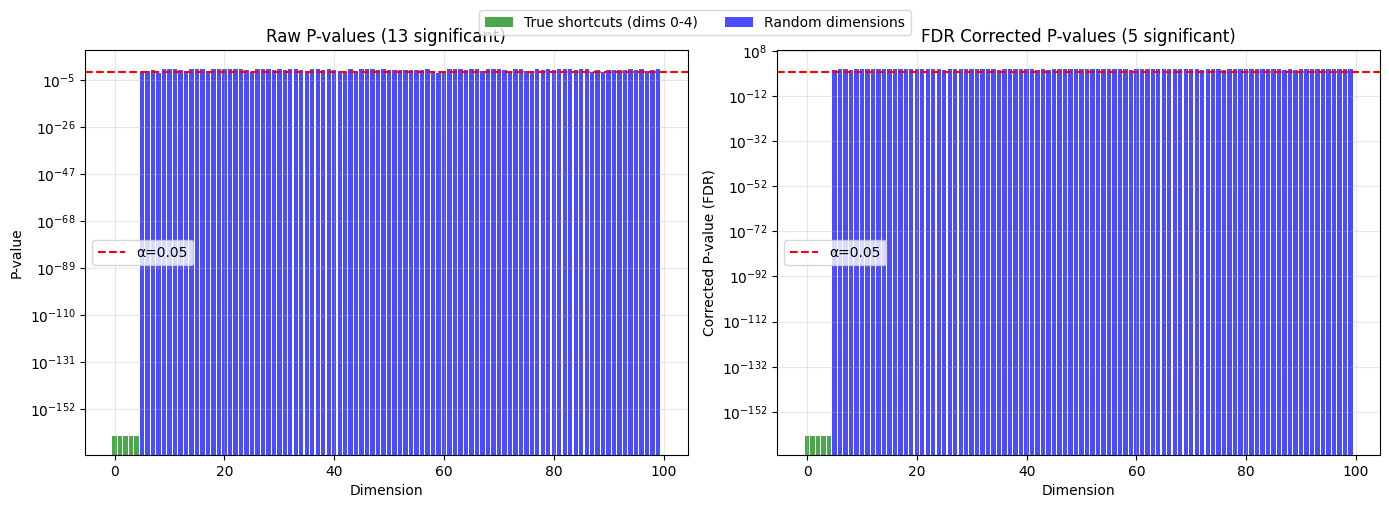

In [16]:
# Visualize raw vs corrected p-values
raw_pvals = test_hd.get_pvalues()['0_vs_1']
corrected_pvals = corrected['corrected_pvalues']['0_vs_1']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Raw p-values
ax1 = axes[0]
colors = ['green' if i < 5 else 'blue' for i in range(100)]
ax1.bar(range(100), raw_pvals, color=colors, alpha=0.7)
ax1.axhline(y=0.05, color='r', linestyle='--', label='α=0.05')
ax1.set_xlabel('Dimension')
ax1.set_ylabel('P-value')
ax1.set_title(f'Raw P-values ({n_raw} significant)')
ax1.set_yscale('log')
ax1.legend()
ax1.grid(alpha=0.3)

# Right: Corrected p-values
ax2 = axes[1]
ax2.bar(range(100), corrected_pvals, color=colors, alpha=0.7)
ax2.axhline(y=0.05, color='r', linestyle='--', label='α=0.05')
ax2.set_xlabel('Dimension')
ax2.set_ylabel('Corrected P-value (FDR)')
ax2.set_title(f'FDR Corrected P-values ({n_corrected} significant)')
ax2.set_yscale('log')
ax2.legend()
ax2.grid(alpha=0.3)

# Add legend for colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', alpha=0.7, label='True shortcuts (dims 0-4)'),
                   Patch(facecolor='blue', alpha=0.7, label='Random dimensions')]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.savefig('../output/multiple_testing_correction.png', dpi=150, bbox_inches='tight')
plt.show()

## Example 5: Using the Unified API with Correction

The `ShortcutDetector` class automatically applies multiple testing correction:

In [17]:
from shortcut_detect import ShortcutDetector

# Default: FDR Benjamini-Hochberg correction
detector = ShortcutDetector(
    methods=['statistical'],
    statistical_correction='fdr_bh',  # Default
    statistical_alpha=0.05
)

detector.fit(embeddings_hd, labels_hd)
print(detector.summary())

Running statistical tests...
✅ Detection complete!
UNIFIED SHORTCUT DETECTION SUMMARY
Dataset: 1000 samples, 100 dimensions
Methods used: statistical

----------------------------------------------------------------------
Statistical Testing
----------------------------------------------------------------------
Comparisons performed: 1
Multiple testing correction: FDR_BH (α=0.05)
Comparisons with significant features: 1
  [0_vs_1]: 5 significant (was 13 before correction)

OVERALL ASSESSMENT
🟡 MODERATE RISK: One method detected shortcuts
  • 1 group comparisons show significant differences


In [18]:
# Try with Bonferroni (more conservative)
detector_bonf = ShortcutDetector(
    methods=['statistical'],
    statistical_correction='bonferroni',
    statistical_alpha=0.05
)

detector_bonf.fit(embeddings_hd, labels_hd)

# Compare results
stat_results = detector.get_results()['statistical']
stat_results_bonf = detector_bonf.get_results()['statistical']

print("Comparison of correction methods via Unified API:")
print("-" * 50)
print(f"FDR (fdr_bh):   {len(stat_results['significant_features']['0_vs_1']) if stat_results['significant_features']['0_vs_1'] else 0} significant")
print(f"Bonferroni:     {len(stat_results_bonf['significant_features']['0_vs_1']) if stat_results_bonf['significant_features']['0_vs_1'] else 0} significant")

Running statistical tests...
✅ Detection complete!
Comparison of correction methods via Unified API:
--------------------------------------------------
FDR (fdr_bh):   5 significant
Bonferroni:     5 significant


## Summary

### When to Use Statistical Testing:
- ✅ Quick and interpretable
- ✅ Works well for high-dimensional data
- ✅ Can identify specific problematic dimensions
- ✅ Multiple test options (parametric/non-parametric)

### Multiple Testing Correction:
- ✅ **Always use correction** when testing many dimensions
- ✅ **FDR (fdr_bh)** is recommended for most applications
- ✅ **Bonferroni** when any false positive is unacceptable
- ✅ Unified API applies correction automatically

### Interpretation:
- **Many low p-values after correction** → Strong shortcuts
- **Few low p-values after correction** → True shortcuts only
- **Check which dimensions** → Actionable insights for mitigation

### References:
- Benjamini, Y., & Hochberg, Y. (1995). Controlling the False Discovery Rate. *JRSS-B*, 57(1), 289-300.

📖 See [docs/multiple_testing_correction.md](../../docs/multiple_testing_correction.md) for more details.